# Synthetic Lamp Image

This notebook renders a synthetic echelle detector frame from a small list of
visible emission lines (Hg, H, He, Ar/Ne) using the LHD CMOS echelle defaults.

**This is a numerical model, not a photograph.**  The x-position of each line
comes from the echelle dispersion formula; the y-position uses a simple uniform
order-spacing model.  This is useful for testing extraction and calibration
logic, not for a full ray-trace simulation.

In [7]:
import matplotlib.pyplot as plt
import numpy as np

from echelle_optics import lhd_cmos_echelle, render_echelle_lines

spec = lhd_cmos_echelle()
orders = list(range(30, 59))

# Emission line list: (wavelength nm, relative intensity)
lines = [
    (404.656, 0.6),   # Hg violet
    (435.833, 0.7),   # Hg blue
    (486.133, 0.8),   # H-beta
    (546.074, 1.0),   # Hg green
    (587.562, 0.9),   # He/Ne yellow
    (656.281, 2.0),   # H-alpha
    (696.543, 0.5),   # Ar/Ne red
    (706.722, 0.4),   # Ar/Ne red
]

# Compact shape for fast rendering; not the full 2560×2160 detector
SHAPE = (640, 1024)
ORDER_SPACING = 21.0   # pixels between adjacent orders

## Grayscale image

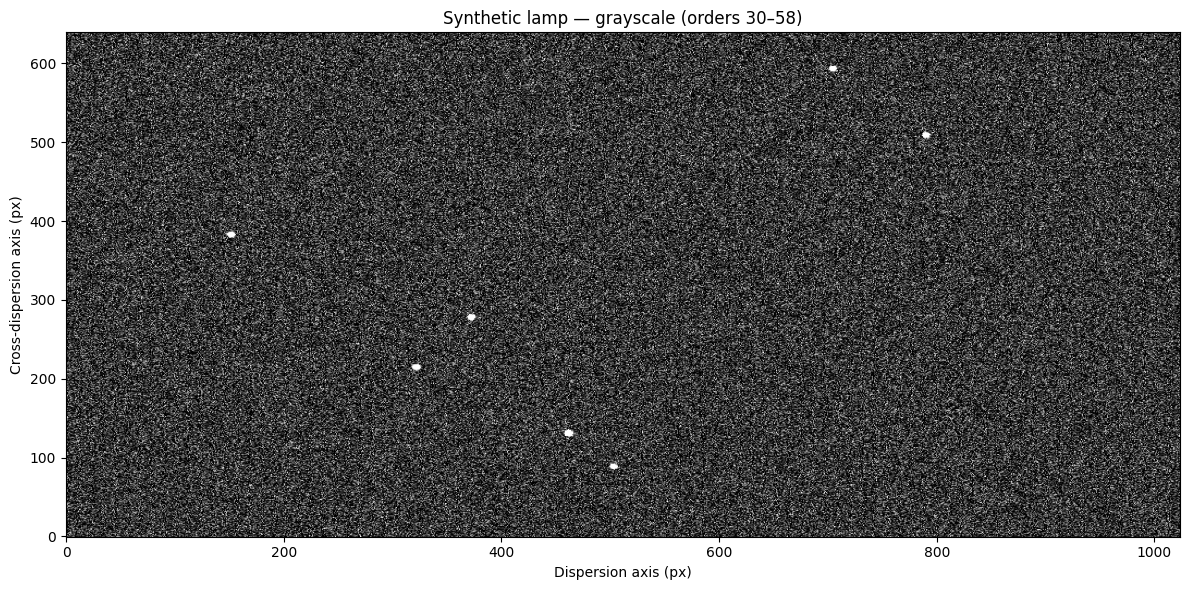

In [8]:
img_gray = render_echelle_lines(
    lines,
    spec,
    orders=orders,
    shape=SHAPE,
    order_spacing_px=ORDER_SPACING,
    psf_sigma_px=1.5,
    color=False,
    background=0.01,
    read_noise=0.02,
    seed=0,
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(
    img_gray,
    origin="lower",
    aspect="auto",
    cmap="gray",
    vmin=0,
    vmax=np.percentile(img_gray, 99.5),
)
ax.set_title("Synthetic lamp — grayscale (orders 30–58)")
ax.set_xlabel("Dispersion axis (px)")
ax.set_ylabel("Cross-dispersion axis (px)")
plt.tight_layout()
plt.show()

## Colour image

Each line is tinted with an approximate visible-spectrum colour
via `wavelength_to_rgb`.  The colour assignment is per-wavelength,
independent of which diffraction order carries the line.

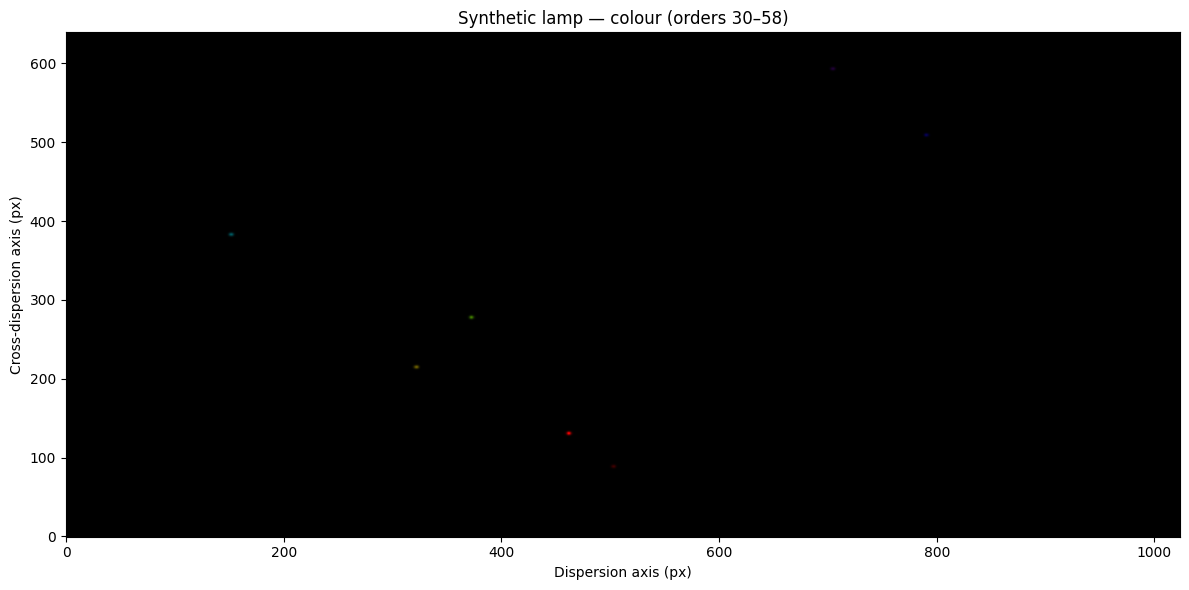

In [9]:
img_color = render_echelle_lines(
    lines,
    spec,
    orders=orders,
    shape=SHAPE,
    order_spacing_px=ORDER_SPACING,
    psf_sigma_px=1.5,
    color=True,
    background=0.0,
    read_noise=0.0,
)

# Normalise for display
display_img = img_color / max(img_color.max(), 1e-6)
display_img = display_img.clip(0, 1)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(display_img, origin="lower", aspect="auto")
ax.set_title("Synthetic lamp — colour (orders 30–58)")
ax.set_xlabel("Dispersion axis (px)")
ax.set_ylabel("Cross-dispersion axis (px)")
plt.tight_layout()
plt.show()

## Notes on the model

| Aspect | What the model does | What it omits |
|---|---|---|
| Dispersion (x) | Grating equation, quasi-Littrow | Prism cross-disperser geometry |
| Order layout (y) | Uniform `order_spacing_px` | Empirical prism curvature, tilt |
| PSF | Symmetric 2-D Gaussian | Anamorphic distortion, aberrations |
| Blaze efficiency | Uniform intensity per order | Blaze envelope roll-off |

This level of fidelity is sufficient for testing spectral extraction and
wavelength-calibration pipelines.